In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

plt.style.use('ggplot')

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving startup_funding (1).csv to startup_funding (1).csv


In [ ]:
df = pd.read_csv('startup_funding (1).csv')

df.head()

,SNo,Date,StartupName,IndustryVertical,SubVertical,CityLocation,InvestorsName,InvestmentType,AmountInUSD,Remarks
0,0,01/08/2017,TouchKin,Technology,Predictive Care Platform,Bangalore,Kae Capital,Private Equity,"1,300,000",NaN
1,1,02/08/2017,Ethinos,Technology,Digital Marketing Agency,Mumbai,Triton Investment Advisors,Private Equity,NaN,NaN
2,2,02/08/2017,Leverage Edu,Consumer Internet,Online platform for Higher Education Services,New Delhi,"Kashyap Deorah, Anand Sankeshwar, Deepak Jain,...",Seed Funding,NaN,NaN
3,3,02/08/2017,Zepo,Consumer Internet,DIY Ecommerce platform,Mumbai,"Kunal Shah, LetsVenture, Anupam Mittal, Hetal ...",Seed Funding,"500,000",NaN
4,4,02/08/2017,Click2Clinic,Consumer Internet,healthcare service aggregator,Hyderabad,"Narottam Thudi, Shireesh Palle",Seed Funding,"850,000",NaN


In [ ]:
print("Shape:", df.shape)

df.info()

df.describe(include='all')

Shape: (2372, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2372 entries, 0 to 2371
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   SNo               2372 non-null   int64 
 1   Date              2372 non-null   object
 2   StartupName       2372 non-null   object
 3   IndustryVertical  2201 non-null   object
 4   SubVertical       1436 non-null   object
 5   CityLocation      2193 non-null   object
 6   InvestorsName     2364 non-null   object
 7   InvestmentType    2371 non-null   object
 8   AmountInUSD       1525 non-null   object
 9   Remarks           419 non-null    object
dtypes: int64(1), object(9)
memory usage: 185.4+ KB


,SNo,Date,StartupName,IndustryVertical,SubVertical,CityLocation,InvestorsName,InvestmentType,AmountInUSD,Remarks
count,2372.000000,2372,2372,2201,1436,2193,2364,2371,1525,419
unique,NaN,701,2001,743,1364,71,1885,7,329,69
top,NaN,02/02/2015,Swiggy,Consumer Internet,Online Pharmacy,Bangalore,Undisclosed Investors,Seed Funding,"1,000,000",Series A
freq,NaN,11,7,772,9,627,33,1271,130,177
mean,1185.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,684.881742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,592.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1185.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1778.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(df.isnull().sum())

df.fillna("Unknown", inplace=True)

SNo                    0
Date                   0
StartupName            0
IndustryVertical     171
SubVertical          936
CityLocation         179
InvestorsName          8
InvestmentType         1
AmountInUSD          847
Remarks             1953
dtype: int64


In [ ]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

Duplicates: 0
New Shape: (2372, 10)


In [ ]:
df['AmountInUSD'] = (
    df['AmountInUSD']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['AmountInUSD'] = pd.to_numeric(
    df['AmountInUSD'],
    errors='coerce'
)

df['AmountInUSD'].fillna(0, inplace=True)

df[['AmountInUSD']].head()

/tmp/ipykernel_12801/1607188726.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AmountInUSD'].fillna(0, inplace=True)


,AmountInUSD
0,1300000.0
1,0.0
2,0.0
3,500000.0
4,850000.0


In [ ]:
df['Funding_Success'] = np.where(
    df['AmountInUSD'] > 0,
    1,
    0
)

df[['AmountInUSD', 'Funding_Success']].head()

,AmountInUSD,Funding_Success
0,1300000.0,1
1,0.0,0
2,0.0,0
3,500000.0,1
4,850000.0,1


In [ ]:
print("Total Startup Records =", len(df))

Total Startup Records = 2372


In [ ]:
print("Mean =", df['AmountInUSD'].mean())
print("Median =", df['AmountInUSD'].median())
print("Standard Deviation =", df['AmountInUSD'].std())

Mean = 7734985.866779089
Median = 300000.0
Standard Deviation = 51658323.53869951


In [ ]:
print(df['AmountInUSD'].quantile([0.25,0.50,0.75]))


print("90th Percentile =", df['AmountInUSD'].quantile(0.90))
print("95th Percentile =", df['AmountInUSD'].quantile(0.95))

0.25          0.0
0.50     300000.0
0.75    2500000.0
Name: AmountInUSD, dtype: float64
90th Percentile = 12480000.000000019
95th Percentile = 26449999.999999817


In [ ]:
industry_prob = df.groupby(
    'IndustryVertical'
)['Funding_Success'].mean()

print(industry_prob.sort_values(
    ascending=False
).head(10))

city_prob = df.groupby(
    'CityLocation'
)['Funding_Success'].mean()

print(city_prob.sort_values(
    ascending=False
).head(10))


IndustryVertical
visual search and discovery platform                        1.0
virtual reality, 3d simulation and stereoscopic products    1.0
3D Printer Manufacturer                                     1.0
API Workflow platform                                       1.0
residential rental management platform                      1.0
hotel booking app                                           1.0
healthcare                                                  1.0
fund raising platform for startups                          1.0
engineering services company                                1.0
eCommerce platform                                          1.0
Name: Funding_Success, dtype: float64
CityLocation
Bangalore / Palo Alto    1.0
Bangalore / USA          1.0
Bangalore / San Mateo    1.0
Bangalore / SFO          1.0
Bangalore/ Bangkok       1.0
Boston                   1.0
Bhopal                   1.0
Belgaum                  1.0
Noida / Singapore        1.0
Panaji                   1.0
Na

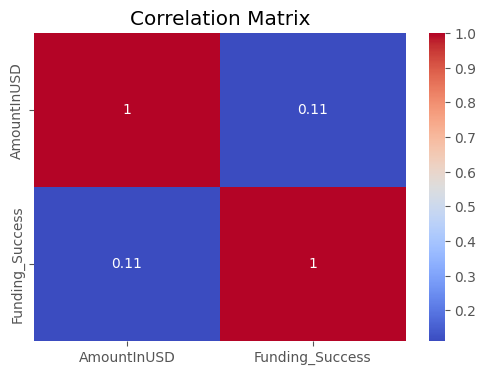

In [13]:
corr = df[['AmountInUSD',
           'Funding_Success']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

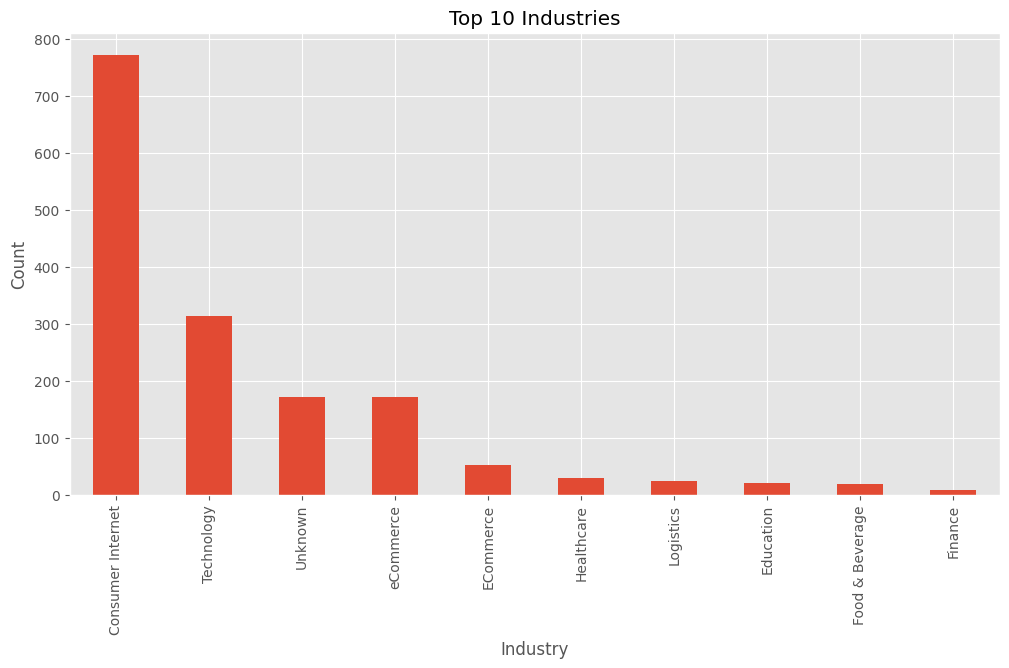

In [14]:
plt.figure(figsize=(12,6))

df['IndustryVertical'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top 10 Industries")
plt.xlabel("Industry")
plt.ylabel("Count")
plt.show()

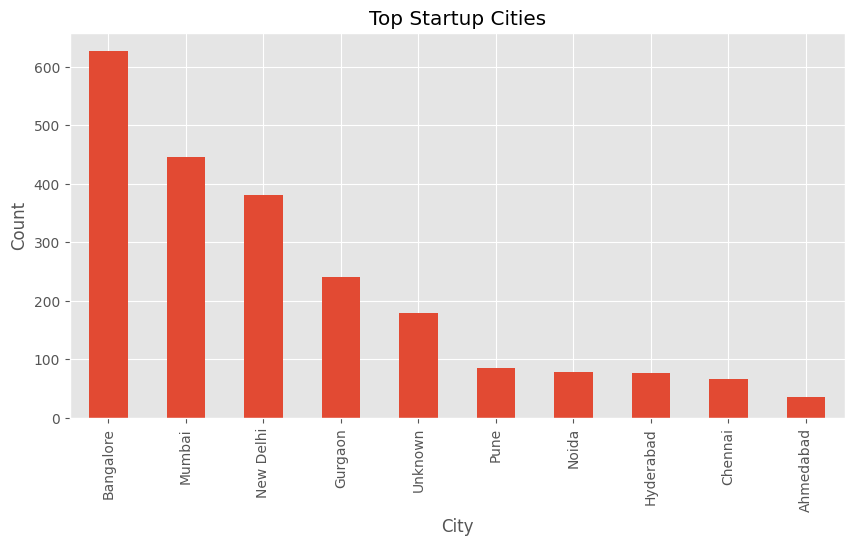

In [15]:
plt.figure(figsize=(10,5))

df['CityLocation'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top Startup Cities")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

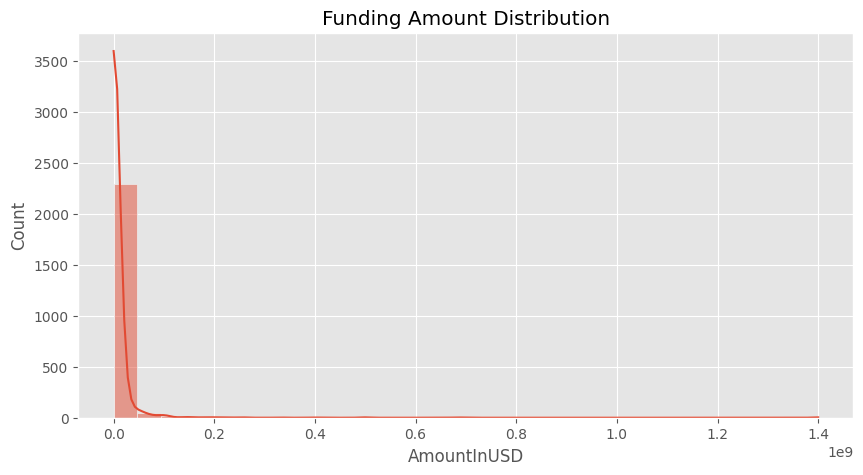

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['AmountInUSD'],
    bins=30,
    kde=True
)

plt.title("Funding Amount Distribution")
plt.show()

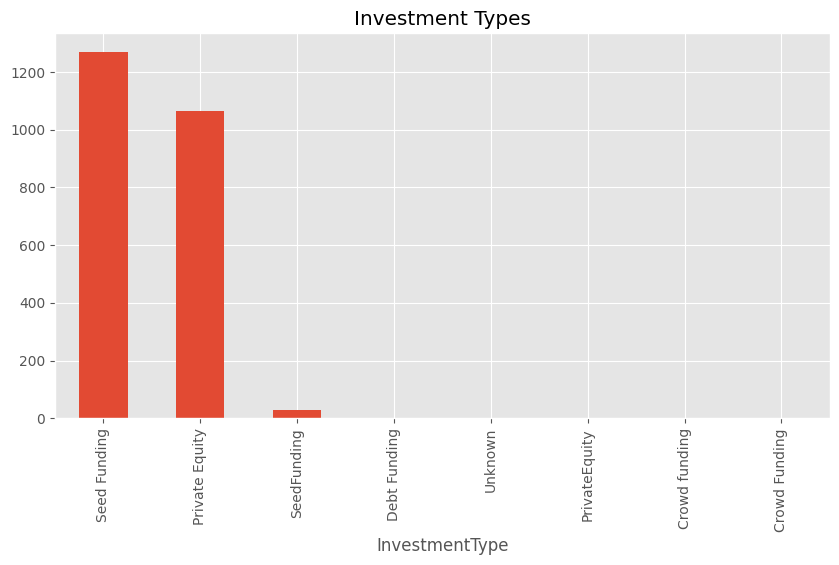

In [17]:
plt.figure(figsize=(10,5))

df['InvestmentType'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Investment Types")
plt.show()

In [18]:
table = pd.crosstab(
    df['IndustryVertical'],
    df['Funding_Success']
)

chi2,p,dof,expected = chi2_contingency(table)

print("Chi Square =", chi2)
print("P Value =", p)

if p < 0.05:
    print("Reject H0")
    print("Industry significantly influences funding success")
else:
    print("Fail to Reject H0")
    print("No significant relationship")

Chi Square = 732.5225995680266
P Value = 0.6009354654707512
Fail to Reject H0
No significant relationship


In [19]:
df['Segment'] = pd.cut(
    df['AmountInUSD'],
    bins=[0,1000000,10000000,50000000,1000000000],
    labels=[
        'Early Stage',
        'Growing Startup',
        'High Growth',
        'Large Funded'
    ]
)

print(df['Segment'].value_counts())

Segment
Early Stage        761
Growing Startup    505
High Growth        197
Large Funded        60
Name: count, dtype: int64


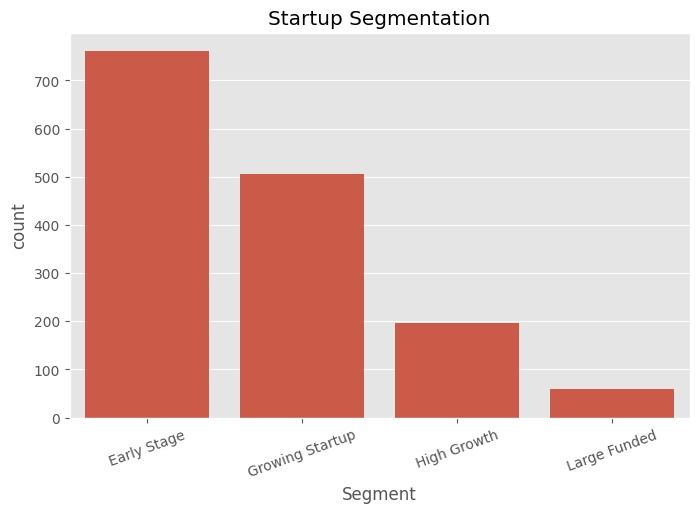

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Segment',
    data=df
)

plt.xticks(rotation=20)

plt.title("Startup Segmentation")

plt.show()

In [21]:
print("Top Industries:")
print(df['IndustryVertical'].value_counts().head())

print("\nTop Cities:")
print(df['CityLocation'].value_counts().head())

print("\nTop Investment Types:")
print(df['InvestmentType'].value_counts().head())

Top Industries:
IndustryVertical
Consumer Internet    772
Technology           313
Unknown              171
eCommerce            171
ECommerce             53
Name: count, dtype: int64

Top Cities:
CityLocation
Bangalore    627
Mumbai       446
New Delhi    381
Gurgaon      240
Unknown      179
Name: count, dtype: int64

Top Investment Types:
InvestmentType
Seed Funding      1271
Private Equity    1066
SeedFunding         30
Debt Funding         1
Unknown              1
Name: count, dtype: int64
